In [1]:
import pandas as pd
import numpy as np
rng = np.random.default_rng()
import matplotlib.pyplot as plt
import matplotlib as mpl
from skimage.measure import block_reduce
import sympy as sp
from sympy.stats import Normal, E , density, MultivariateNormal

#### Functions

In [2]:
def multivariate_lognormal_cascade(n, sigma1=1, sigma2=1, corr=0):
    mu1 = -1/2 * sigma1**2
    mu2 = -1/2 * sigma2**2

    PQ = np.exp(rng.multivariate_normal(np.array([mu1,mu2]),  np.array([[sigma1**2,corr*sigma1*sigma2], [corr*sigma1*sigma2, sigma2**2]]), 4))

    P = PQ[:,0].reshape(2,2)
    Q = PQ[:,1].reshape(2,2)
    for i in range(n):
        PQ = np.exp(rng.multivariate_normal(np.array([mu1,mu2]),np.array([[sigma1**2,corr*sigma1*sigma2], [corr*sigma1*sigma2, sigma2**2]]), P.shape[0]**2 * 4))
        P = np.kron(P, np.ones((2,2)))
        P = P * PQ[:,0].reshape(P.shape)
        Q = np.kron(Q, np.ones((2,2)))
        Q = Q * PQ[:,1].reshape(P.shape)

    P = P / np.sum(P)
    Q = Q / np.sum(Q)
    return(np.stack([P,Q], axis=-1))

def Theil(pop):
  tp = pop.sum(axis=2)
  prob = pop[:,:,:] / tp[:,:, np.newaxis]
  ep = np.sum(-np.log2(prob) * prob, axis=2)
  e = (ep * tp / 2).sum()
  return(1-e)

First, perform taylor serie of the entropy

In [152]:
Z, z = sp.symbols('Z z')

r1 = 1 / (1 + Z)
r2 = Z / (1 + Z)

H = - r1 * sp.log(r1, 2) - r2 * sp.log(r2, 2) 
H = H.subs({Z : sp.exp(z) })


# Développement d'ordre 5
DL = sp.series(H, z, 0, 11).removeO().expand()
DL

-31*z**10/(1612800*log(2)) + 17*z**8/(92160*log(2)) - z**6/(576*log(2)) + z**4/(64*log(2)) - z**2/(8*log(2)) + 1

In [7]:
from sympy import symbols, exp, diff, Rational

s = symbols('s')

def E_expU_Vk(k, mu_u, su2, mu_v, sv2, suv):
    M = exp(
        mu_u + Rational(1,2)*su2
        + s*(mu_v + suv)
        + Rational(1,2)*sv2*s**2
    )
    return diff(M, s, k).subs(s, 0).expand()

#### coefficient power 2

In [8]:
sigma1, sigma2, t, rho = sp.symbols('sigma_1 sigma_2 t rho')

In [9]:
k, mu1, s1, mu2, s2, s12 = sp.symbols('k mu_1 s_1 mu_2 s_2 s_12')

In [10]:
test = E_expU_Vk(2, mu1, s1, mu2, s2, s12)
E1 = test.subs({mu1 : t * (-sigma1**2/2),
           mu2 : t *( -sigma1**2/2+sigma2**2/2),
           s1 : t * sigma1**2,
           s2 : t * (sigma1**2 + sigma2**2 - 2 * rho * sigma1 * sigma2),
           s12 : t * (sigma1**2 - rho * sigma1 * sigma2)})
E2 = test.subs({mu1 :t * (-sigma2**2/2),
           mu2 : t *(-sigma1**2/2+sigma2**2/2),
           s1 : t* (sigma2**2),
           s2 : t * (sigma1**2 + sigma2**2 - 2 * rho * sigma1 * sigma2),
           s12 : t *(-sigma2**2 + rho * sigma1 * sigma2)})

In [293]:
coeff2 = sp.collect(sp.factor((E1 + E2)/2), t)
coeff2

t*(t*(2*rho*sigma_1*sigma_2 - sigma_1**2 - sigma_2**2) - 4)*(2*rho*sigma_1*sigma_2 - sigma_1**2 - sigma_2**2)/4

In [294]:
d = sigma1**2 + sigma2**2 - 2* rho * sigma1 * sigma2

In [295]:
d

-2*rho*sigma_1*sigma_2 + sigma_1**2 + sigma_2**2

In [296]:
expr_coeff2 = 1/4 * t * d * (t*d + 4) 

In [297]:
coeff2.equals(expr_coeff2)

True

#### coefficient power 4

In [195]:
test = E_expU_Vk(4, mu1, s1, mu2, s2, s12)
E1 = test.subs({mu1 : t * (-sigma1**2/2),
           mu2 : t *( -sigma1**2/2+sigma2**2/2),
           s1 : t * sigma1**2,
           s2 : t * (sigma1**2 + sigma2**2 - 2 * rho * sigma1 * sigma2),
           s12 : t * (sigma1**2 - rho * sigma1 * sigma2)})
E2 = test.subs({mu1 :t * (-sigma2**2/2),
           mu2 : t *(-sigma1**2/2+sigma2**2/2),
           s1 : t* (sigma2**2),
           s2 : t * (sigma1**2 + sigma2**2 - 2 * rho * sigma1 * sigma2),
           s12 : t *(-sigma2**2 + rho * sigma1 * sigma2)})

In [196]:
coeff4= sp.collect(sp.factor((E1 + E2)/2), t)
coeff4

t**2*(t**2*(4*rho**2*sigma_1**2*sigma_2**2 - 4*rho*sigma_1**3*sigma_2 - 4*rho*sigma_1*sigma_2**3 + sigma_1**4 + 2*sigma_1**2*sigma_2**2 + sigma_2**4) + t*(-48*rho*sigma_1*sigma_2 + 24*sigma_1**2 + 24*sigma_2**2) + 48)*(2*rho*sigma_1*sigma_2 - sigma_1**2 - sigma_2**2)**2/16

In [200]:
expr_coeff4 = 1/16 * t**2 * d**2 * (t**2 * d**2 + 24 * t * d + 48 ) 

In [201]:
coeff4.equals(expr_coeff4)

True

#### coefficient power 6

In [203]:
test = E_expU_Vk(6, mu1, s1, mu2, s2, s12)
E1 = test.subs({mu1 : t * (-sigma1**2/2),
           mu2 : t *( -sigma1**2/2+sigma2**2/2),
           s1 : t * sigma1**2,
           s2 : t * (sigma1**2 + sigma2**2 - 2 * rho * sigma1 * sigma2),
           s12 : t * (sigma1**2 - rho * sigma1 * sigma2)})
E2 = test.subs({mu1 :t * (-sigma2**2/2),
           mu2 : t *(-sigma1**2/2+sigma2**2/2),
           s1 : t* (sigma2**2),
           s2 : t * (sigma1**2 + sigma2**2 - 2 * rho * sigma1 * sigma2),
           s12 : t *(-sigma2**2 + rho * sigma1 * sigma2)})

In [204]:
coeff6= sp.collect(sp.factor((E1 + E2)/2), t)
coeff6

t**3*(2*rho*sigma_1*sigma_2 - sigma_1**2 - sigma_2**2)**3*(t**3*(8*rho**3*sigma_1**3*sigma_2**3 - 12*rho**2*sigma_1**4*sigma_2**2 - 12*rho**2*sigma_1**2*sigma_2**4 + 6*rho*sigma_1**5*sigma_2 + 12*rho*sigma_1**3*sigma_2**3 + 6*rho*sigma_1*sigma_2**5 - sigma_1**6 - 3*sigma_1**4*sigma_2**2 - 3*sigma_1**2*sigma_2**4 - sigma_2**6) + t**2*(-240*rho**2*sigma_1**2*sigma_2**2 + 240*rho*sigma_1**3*sigma_2 + 240*rho*sigma_1*sigma_2**3 - 60*sigma_1**4 - 120*sigma_1**2*sigma_2**2 - 60*sigma_2**4) + t*(1440*rho*sigma_1*sigma_2 - 720*sigma_1**2 - 720*sigma_2**2) - 960)/64

In [210]:
expr_coeff6 = 1 /64 * t**3 * d**3 * (t**3 * d**3 + 60 * t**2 * d**2 + 720 * t * d + 960) 

In [211]:
expr_coeff6

0.015625*t**3*(-2*rho*sigma_1*sigma_2 + sigma_1**2 + sigma_2**2)**3*(t**3*(-2*rho*sigma_1*sigma_2 + sigma_1**2 + sigma_2**2)**3 + 60*t**2*(-2*rho*sigma_1*sigma_2 + sigma_1**2 + sigma_2**2)**2 + 720*t*(-2*rho*sigma_1*sigma_2 + sigma_1**2 + sigma_2**2) + 960)

In [212]:
coeff6.equals(expr_coeff6)

True

#### coefficient power 8

In [263]:
test = E_expU_Vk(8, mu1, s1, mu2, s2, s12)
E1 = test.subs({mu1 : t * (-sigma1**2/2),
           mu2 : t *( -sigma1**2/2+sigma2**2/2),
           s1 : t * sigma1**2,
           s2 : t * (sigma1**2 + sigma2**2 - 2 * rho * sigma1 * sigma2),
           s12 : t * (sigma1**2 - rho * sigma1 * sigma2)})
E2 = test.subs({mu1 :t * (-sigma2**2/2),
           mu2 : t *(-sigma1**2/2+sigma2**2/2),
           s1 : t* (sigma2**2),
           s2 : t * (sigma1**2 + sigma2**2 - 2 * rho * sigma1 * sigma2),
           s12 : t *(-sigma2**2 + rho * sigma1 * sigma2)})

In [264]:
coeff8= sp.collect(sp.factor((E1 + E2)/2), t)
coeff8

t**4*(2*rho*sigma_1*sigma_2 - sigma_1**2 - sigma_2**2)**4*(t**4*(16*rho**4*sigma_1**4*sigma_2**4 - 32*rho**3*sigma_1**5*sigma_2**3 - 32*rho**3*sigma_1**3*sigma_2**5 + 24*rho**2*sigma_1**6*sigma_2**2 + 48*rho**2*sigma_1**4*sigma_2**4 + 24*rho**2*sigma_1**2*sigma_2**6 - 8*rho*sigma_1**7*sigma_2 - 24*rho*sigma_1**5*sigma_2**3 - 24*rho*sigma_1**3*sigma_2**5 - 8*rho*sigma_1*sigma_2**7 + sigma_1**8 + 4*sigma_1**6*sigma_2**2 + 6*sigma_1**4*sigma_2**4 + 4*sigma_1**2*sigma_2**6 + sigma_2**8) + t**3*(-896*rho**3*sigma_1**3*sigma_2**3 + 1344*rho**2*sigma_1**4*sigma_2**2 + 1344*rho**2*sigma_1**2*sigma_2**4 - 672*rho*sigma_1**5*sigma_2 - 1344*rho*sigma_1**3*sigma_2**3 - 672*rho*sigma_1*sigma_2**5 + 112*sigma_1**6 + 336*sigma_1**4*sigma_2**2 + 336*sigma_1**2*sigma_2**4 + 112*sigma_2**6) + t**2*(13440*rho**2*sigma_1**2*sigma_2**2 - 13440*rho*sigma_1**3*sigma_2 - 13440*rho*sigma_1*sigma_2**3 + 3360*sigma_1**4 + 6720*sigma_1**2*sigma_2**2 + 3360*sigma_2**4) + t*(-53760*rho*sigma_1*sigma_2 + 26880*sigma

In [274]:
expr_coeff8 = 1/256 * t**4 * d**4 * (t**4 * d**4 + 112 * t**3 * d**3 + 3360 * t**2 * d**2 + 26880 * t * d + 26880)

In [275]:
coeff8.equals(expr_coeff8)

True

#### coefficient power 10

In [299]:
test = E_expU_Vk(10, mu1, s1, mu2, s2, s12)
E1 = test.subs({mu1 : t * (-sigma1**2/2),
           mu2 : t *( -sigma1**2/2+sigma2**2/2),
           s1 : t * sigma1**2,
           s2 : t * (sigma1**2 + sigma2**2 - 2 * rho * sigma1 * sigma2),
           s12 : t * (sigma1**2 - rho * sigma1 * sigma2)})
E2 = test.subs({mu1 :t * (-sigma2**2/2),
           mu2 : t *(-sigma1**2/2+sigma2**2/2),
           s1 : t* (sigma2**2),
           s2 : t * (sigma1**2 + sigma2**2 - 2 * rho * sigma1 * sigma2),
           s12 : t *(-sigma2**2 + rho * sigma1 * sigma2)})

In [302]:
coeff10= sp.collect(sp.factor((E1 + E2)/2), t)
coeff10 

t**5*(2*rho*sigma_1*sigma_2 - sigma_1**2 - sigma_2**2)**5*(t**5*(32*rho**5*sigma_1**5*sigma_2**5 - 80*rho**4*sigma_1**6*sigma_2**4 - 80*rho**4*sigma_1**4*sigma_2**6 + 80*rho**3*sigma_1**7*sigma_2**3 + 160*rho**3*sigma_1**5*sigma_2**5 + 80*rho**3*sigma_1**3*sigma_2**7 - 40*rho**2*sigma_1**8*sigma_2**2 - 120*rho**2*sigma_1**6*sigma_2**4 - 120*rho**2*sigma_1**4*sigma_2**6 - 40*rho**2*sigma_1**2*sigma_2**8 + 10*rho*sigma_1**9*sigma_2 + 40*rho*sigma_1**7*sigma_2**3 + 60*rho*sigma_1**5*sigma_2**5 + 40*rho*sigma_1**3*sigma_2**7 + 10*rho*sigma_1*sigma_2**9 - sigma_1**10 - 5*sigma_1**8*sigma_2**2 - 10*sigma_1**6*sigma_2**4 - 10*sigma_1**4*sigma_2**6 - 5*sigma_1**2*sigma_2**8 - sigma_2**10) + t**4*(-2880*rho**4*sigma_1**4*sigma_2**4 + 5760*rho**3*sigma_1**5*sigma_2**3 + 5760*rho**3*sigma_1**3*sigma_2**5 - 4320*rho**2*sigma_1**6*sigma_2**2 - 8640*rho**2*sigma_1**4*sigma_2**4 - 4320*rho**2*sigma_1**2*sigma_2**6 + 1440*rho*sigma_1**7*sigma_2 + 4320*rho*sigma_1**5*sigma_2**3 + 4320*rho*sigma_1**3*si

In [303]:
expr_coeff10 = 1/1024 * t**5 * d**5 * (t**5 * d**5 + 180 * t**4 * d**4 + 10080 * t**3 * d**3 + 201600 * t**2 * d**2 + 1209600 * t* d + 967680) 

In [304]:
coeff10.equals(expr_coeff10)

True

#### Combine and test

In [11]:
1 - DL

31*z**10/(1612800*log(2)) - 17*z**8/(92160*log(2)) + z**6/(576*log(2)) - z**4/(64*log(2)) + z**2/(8*log(2))

In [153]:
d, t = sp.symbols('d t')

expr_coeff2 = 1/4 * t * d * (t*d + 4) 
expr_coeff4 = 1/16 * t**2 * d**2 * (t**2 * d**2 + 24 * t * d + 48 ) 
expr_coeff6 = 1 /64 * t**3 * d**3 * (t**3 * d**3 + 60 * t**2 * d**2 + 720 * t * d + 960) 
expr_coeff8 = 1/256 * t**4 * d**4 * (t**4 * d**4 + 112 * t**3 * d**3 + 3360 * t**2 * d**2 + 26880 * t * d + 26880)
expr_coeff10 = 1/1024 * t**5 * d**5 * (t**5 * d**5 + 180 * t**4 * d**4 + 10080 * t**3 * d**3 + 201600 * t**2 * d**2 + 1209600 * t* d + 967680) 

approx = expr_coeff2 / (8 * sp.log(2)) -  expr_coeff4 / (64 * sp.log(2))  + expr_coeff6 / (576 * sp.log(2)) - 17 / (92160 * sp.log(2)) * expr_coeff8 + 31/( 1612800* sp.log(2))  * expr_coeff10

approx = approx.expand()

approx

1.87707325768849e-8*d**10*t**10/log(2) + 3.37873186383929e-6*d**9*t**9/log(2) + 0.000188488430447049*d**8*t**8/log(2) + 0.00370347764756944*d**7*t**7/log(2) + 0.0203111436631944*d**6*t**6/log(2) + 0.000423177083333337*d**5*t**5/log(2) - 0.000813802083333332*d**4*t**4/log(2) + 0.00260416666666666*d**3*t**3/log(2) - 0.015625*d**2*t**2/log(2) + 0.125*d*t/log(2)

In [154]:


approx = sp.Poly(approx.expand(), t)
approx = sum(
    coeff * t**exp
    for (exp,), coeff in approx.terms()
    if exp <= 2
)


In [155]:
approx

-0.015625*d**2*t**2/log(2) + 0.125*d*t/log(2)

In [156]:
approx = sp.lambdify((t,d), approx)

In [157]:
approx(6,.11)

0.10920299775128899

In [158]:
.5**.5

0.7071067811865476

C:\Users\francois.semecurbe\AppData\Local\Temp\ipykernel_14836\928549418.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


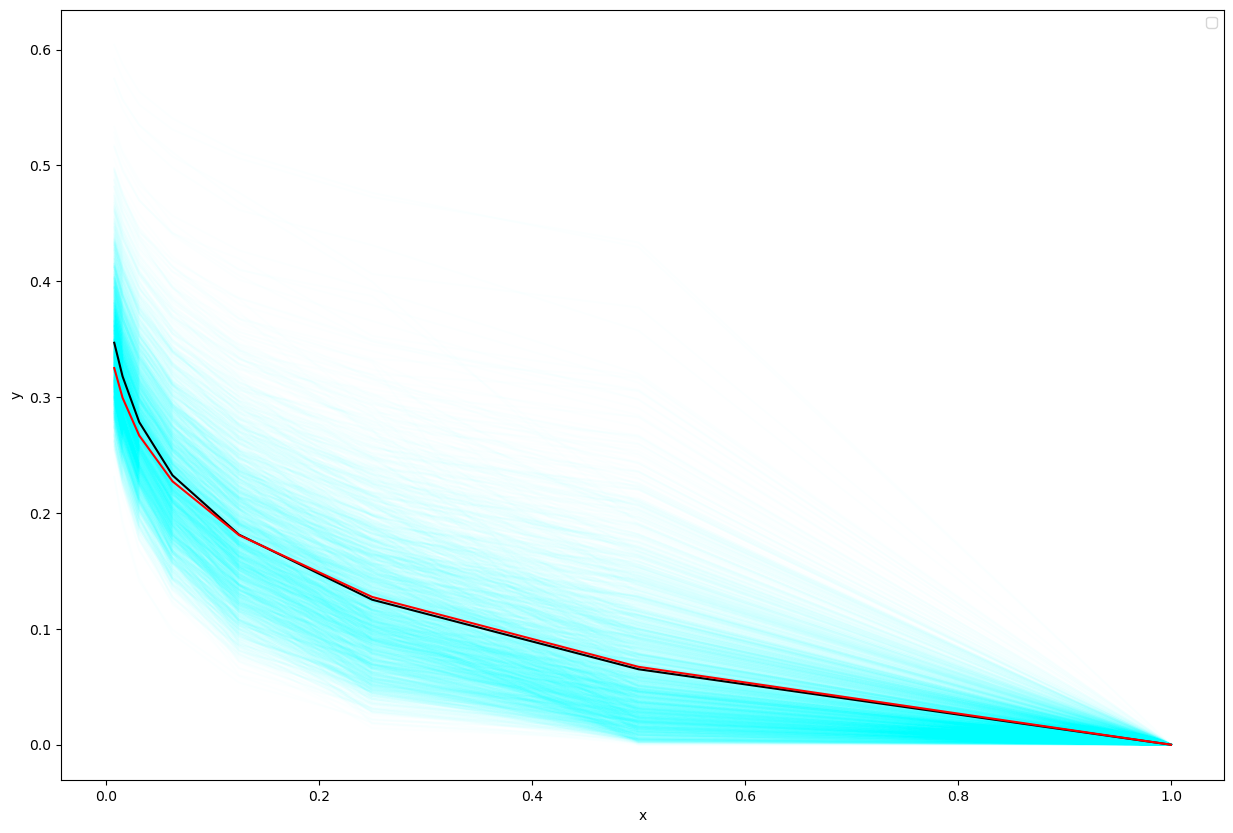

0.3919999999999999


In [163]:

rng = np.random.default_rng()

sizes = 2**np.arange(8) 

sigma1 = .7
sigma2 = .7
rho=.6
k=20

d = sigma1**2 + sigma2**2 - 2 * rho * sigma1 *sigma2
theils = []
theils_hat = []
for i in range(3000):
    lnc = multivariate_lognormal_cascade(6, sigma1=sigma1, sigma2=sigma2, corr=rho)
    theil = []
    for i in sizes:
        temp = block_reduce(lnc, block_size = (i,i,1), func = np.sum)
        theil.append(Theil(temp))
        
    theils.append(theil)

theils = np.array(theils)
theil_expected = np.mean(theils, axis=0)

theil_hat_expected = np.array([  approx(t,d) for t in np.log2(sizes)] )
theil_hat_expected=theil_hat_expected[range(7,-1, -1, )]
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
ax
ax.plot(sizes/128,  theils.T, color='aqua', alpha=0.01)
ax.plot(sizes/128,  theil_expected, color='black', alpha=1)
ax.plot(sizes/128,  theil_hat_expected, color='red', alpha=1)

#ax.set_ylim(0, .020)
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

print(d)

#### In this part, we test if for large value of sigma1 and sigma2, the theil index is still a function of d

In [333]:
rng = np.random.default_rng()

sizes = 2**np.arange(8) 

sigma1 = .45
sigma2 = .35
rho=-1
k=20

d = sigma1**2 + sigma2**2 - 2 * rho * sigma1 *sigma2
theils = []
theils_hat = []
for i in range(5000):
    lnc = multivariate_lognormal_cascade(6, sigma1=sigma1, sigma2=sigma2, corr=rho)
    theil = []
    for i in sizes:
        temp = block_reduce(lnc, block_size = (i,i,1), func = np.sum)
        theil.append(Theil(temp))
        
    theils.append(theil)

theils = np.array(theils)
theil_expected1 = np.mean(theils, axis=0)

sigma1 = .45
sigma2 = (d-sigma1**2)**.5
rho=0


theils = []
theils_hat = []
for i in range(5000):
    lnc = multivariate_lognormal_cascade(6, sigma1=sigma1, sigma2=sigma2, corr=rho)
    theil = []
    for i in sizes:
        temp = block_reduce(lnc, block_size = (i,i,1), func = np.sum)
        theil.append(Theil(temp))
        
    theils.append(theil)

theils = np.array(theils)
theil_expected2 = np.mean(theils, axis=0)

print(d)

0.6400000000000001


C:\Users\francois.semecurbe\AppData\Local\Temp\ipykernel_11656\768303270.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


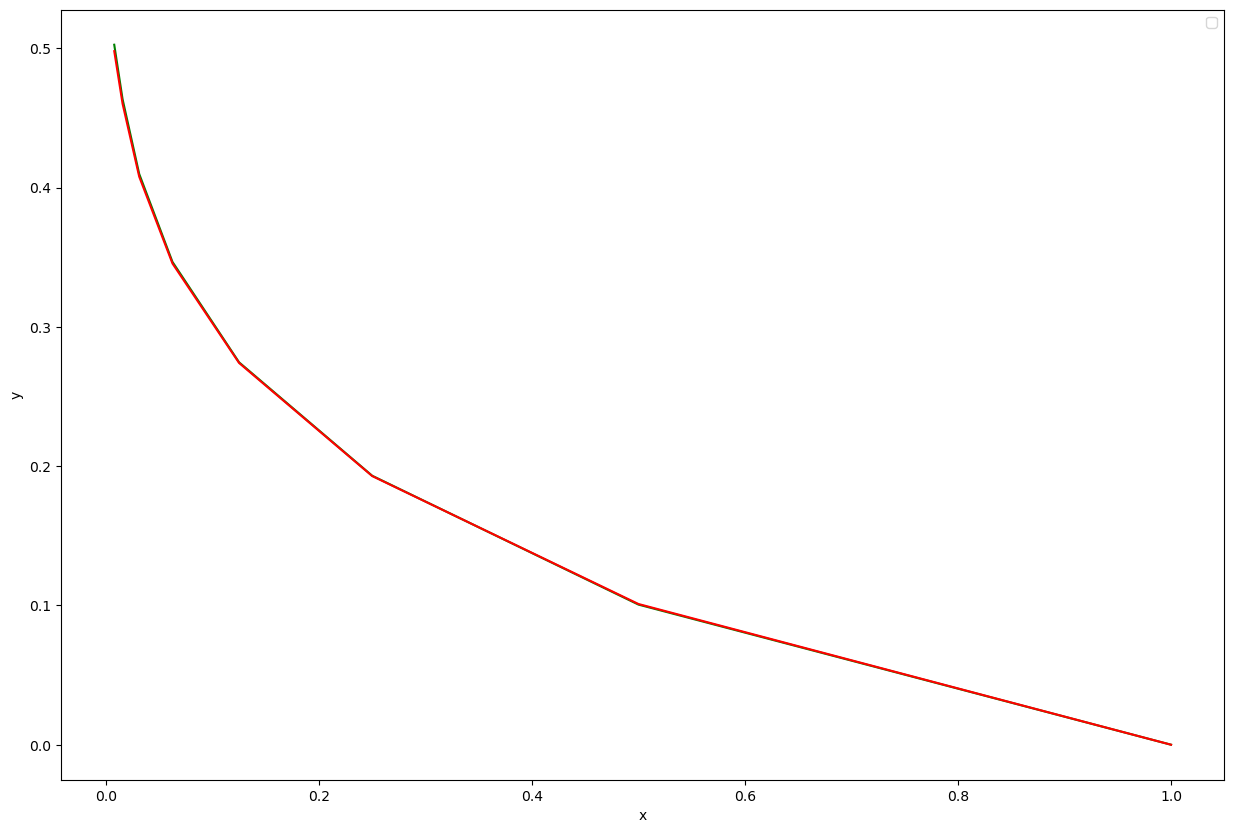

In [335]:
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
ax.plot(sizes/128,  theil_expected1, color='green', alpha=1)
ax.plot(sizes/128,  theil_expected2, color='red', alpha=1)

#ax.set_ylim(0, .020)
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [336]:
d

0.6400000000000001